# Notebook 1: Code Generator with Tools

**Cursor Feature We're Building:** Chat — generate code from natural language, with file operations

In this notebook we build the core of any AI coding editor: an agent that takes a natural language prompt, generates code, and can read/write files. This is the foundation that Cursor's Chat and Agent Mode are built on.

### What's New

| Concept | Why |
|---|---|
| `@tool` decorator | Cleaner than `Tool()` class — schema auto-generated from type hints |
| `bind_tools` | Attach tools directly to the LLM so it decides when to call them |
| `ToolNode` | LangGraph's built-in node that executes tool calls automatically |
| `MessagesState` | Pre-built state with message list + reducer — replaces manual `TypedDict` |
| `astream_events` | Stream tokens in real-time as the agent thinks |

In [6]:
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("OPENROUTER_API_KEY")
print("API Key loaded" if api_key else "API Key NOT found")

API Key loaded


## Setting up the LLM

We use `ChatOpenAI` pointed at OpenRouter. This is the same model interface you saw in Day 10, but now we'll attach tools to it.

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    openai_api_key=api_key,
    openai_api_base="https://openrouter.ai/api/v1",
)

response = llm.invoke("Say hello in one sentence.")
print(response.content)

## Defining Tools with `@tool`

In Day 10 you created tools using `Tool(name=..., func=..., description=...)`. The `@tool` decorator is the modern approach — it reads the function's docstring and type hints to auto-generate the tool schema.

Every coding editor needs file operations. Let's build three tools an agent needs to work with code files.

In [4]:
from langchain_core.tools import tool


@tool
def read_file(filepath: str) -> str:
    """Read the contents of a file and return it as a string."""
    with open(filepath, "r") as f:
        return f.read()


@tool
def write_file(filepath: str, content: str) -> str:
    """Write content to a file. Creates the file if it doesn't exist."""
    os.makedirs(os.path.dirname(filepath) or ".", exist_ok=True)
    with open(filepath, "w") as f:
        f.write(content)
    return f"File written: {filepath}"


@tool
def list_directory(directory: str) -> str:
    """List all files and directories in the given path."""
    entries = os.listdir(directory)
    return "\n".join(entries)


tools = [read_file, write_file, list_directory]

# The decorator auto-generates the schema from the docstring + type hints
for t in tools:
    print(f"{t.name}: {t.description}")
    print(f"  Schema: {t.args_schema.model_json_schema()}\n")

read_file: Read the contents of a file and return it as a string.
  Schema: {'description': 'Read the contents of a file and return it as a string.', 'properties': {'filepath': {'title': 'Filepath', 'type': 'string'}}, 'required': ['filepath'], 'title': 'read_file', 'type': 'object'}

write_file: Write content to a file. Creates the file if it doesn't exist.
  Schema: {'description': "Write content to a file. Creates the file if it doesn't exist.", 'properties': {'filepath': {'title': 'Filepath', 'type': 'string'}, 'content': {'title': 'Content', 'type': 'string'}}, 'required': ['filepath', 'content'], 'title': 'write_file', 'type': 'object'}

list_directory: List all files and directories in the given path.
  Schema: {'description': 'List all files and directories in the given path.', 'properties': {'directory': {'title': 'Directory', 'type': 'string'}}, 'required': ['directory'], 'title': 'list_directory', 'type': 'object'}



## `bind_tools` — Let the LLM Decide When to Use Tools

In Day 10 you used `AgentExecutor` which handled tool routing for you. With LangGraph, we have more control.

`bind_tools` tells the LLM about available tools. The LLM then returns **tool call messages** when it wants to use one, instead of plain text.

In [5]:
llm_with_tools = llm.bind_tools(tools)

# When we ask something that needs a tool, the LLM returns a tool_call
response = llm_with_tools.invoke("What files are in the current directory?")

print("Content:", response.content)
print("Tool calls:", response.tool_calls)

Content: 
Tool calls: [{'name': 'list_directory', 'args': {'directory': '.'}, 'id': 'call_rnHpBkJOxk31ZUHATWOsZYFh', 'type': 'tool_call'}]


In [6]:
# When we ask something that does NOT need a tool, it responds normally
response = llm_with_tools.invoke("What is Python?")

print("Content:", response.content[:200])
print("Tool calls:", response.tool_calls)

Content: Python is a high-level, interpreted programming language known for its clear syntax and readability, making it an excellent choice for both beginners and experienced developers. It was created by Guid
Tool calls: []


The LLM doesn't execute the tool — it just says *which* tool to call and *with what arguments*. We need something to actually run it.

## Building the Agent Graph

In Day 11 you built graphs with `TypedDict` state and manual tool execution. Now we use two upgrades:

- **`MessagesState`** — a pre-built state that holds a list of messages with a built-in reducer (appends new messages automatically)
- **`ToolNode`** — a pre-built node that looks at the last AI message, executes any tool calls, and returns the results as messages

This is the **Agent Loop** pattern: the agent thinks, optionally calls tools, observes results, and repeats until done.

In [7]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langgraph.prebuilt import ToolNode


def agent(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


def should_continue(state: MessagesState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return END


graph = StateGraph(MessagesState)

graph.add_node("agent", agent)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "agent")
graph.add_conditional_edges("agent", should_continue, ["tools", END])
graph.add_edge("tools", "agent")

app = graph.compile()
print("Graph compiled")

Graph compiled


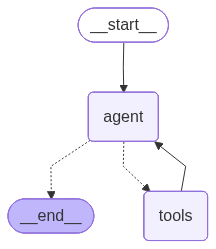

In [8]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

This is the same graph pattern Cursor uses internally — an LLM node connected to tools in a loop. The LLM decides when to call a tool and when it's done.

## Running the Agent

In [9]:
from langchain_core.messages import HumanMessage

result = app.invoke(
    {"messages": [HumanMessage(content="List the files in the current directory")]}
)

# print(result)

for msg in result["messages"]:
    print(f"{msg.type}: {msg.content[:200]}")
    if hasattr(msg, 'tool_calls') and msg.tool_calls:
        print(f"  -> Tool calls: {msg.tool_calls}")
    print()

human: List the files in the current directory

ai: 
  -> Tool calls: [{'name': 'list_directory', 'args': {'directory': '.'}, 'id': 'call_eVUDxB51E91LzjmwTRDVQpLO', 'type': 'tool_call'}]

tool: 03_production_coding_agent.ipynb
orion
README.md
02_self_correcting_code_agent.ipynb
CONTENTS.md
01_code_generator_with_tools.ipynb
sample_project

ai: The files in the current directory are:

- 03_production_coding_agent.ipynb
- 02_self_correcting_code_agent.ipynb
- 01_code_generator_with_tools.ipynb
- README.md
- CONTENTS.md
- orion (directory)
- s



## Code Generation Task

Now a real coding task — the agent should generate code and write it to a file.

In [10]:
result = app.invoke(
    {
        "messages": [
            HumanMessage(
                content="""
Create a Python file called 'generated/calculator.py' with a Calculator class that has:
- add, subtract, multiply, divide methods
- A history list that tracks all operations
- A get_history method that returns the history

Write the file using the write_file tool.
"""
            )
        ]
    }
)

for msg in result["messages"]:
    print(f"[{msg.type}]")
    if hasattr(msg, "tool_calls") and msg.tool_calls:
        for tc in msg.tool_calls:
            print(f"  Tool: {tc['name']}({list(tc['args'].keys())})")
    else:
        print(f"  {msg.content[:300]}")
    print()

[human]
  
Create a Python file called 'generated/calculator.py' with a Calculator class that has:
- add, subtract, multiply, divide methods
- A history list that tracks all operations
- A get_history method that returns the history

Write the file using the write_file tool.


[ai]
  Tool: write_file(['filepath', 'content'])

[tool]
  File written: generated/calculator.py

[ai]
  The Python file `generated/calculator.py` has been created with the requested `Calculator` class. Here are the details of the class:

- It includes methods for addition, subtraction, multiplication, and division.
- It maintains a history list to track all operations.
- The `get_history` method retur



In [11]:
# Verify the file was created
print(open("generated/calculator.py").read())

class Calculator:
    def __init__(self):
        self.history = []

    def add(self, a, b):
        result = a + b
        self.history.append(f'Added {a} + {b} = {result}')
        return result

    def subtract(self, a, b):
        result = a - b
        self.history.append(f'Subtracted {a} - {b} = {result}')
        return result

    def multiply(self, a, b):
        result = a * b
        self.history.append(f'Multiplied {a} * {b} = {result}')
        return result

    def divide(self, a, b):
        if b == 0:
            raise ValueError('Cannot divide by zero')
        result = a / b
        self.history.append(f'Divided {a} / {b} = {result}')
        return result

    def get_history(self):
        return self.history


## Adding a System Prompt

Right now the agent has no personality or constraints. In Cursor, the system prompt shapes the agent's behavior — what kind of code to write, what conventions to follow. This is equivalent to Cursor Rules (`.cursorrules`).

To explore system prompts more you can refer to this GitHub Repository - [system-prompts-and-models-of-ai-tools](https://github.com/x1xhlol/system-prompts-and-models-of-ai-tools/tree/main)

In [12]:
from langchain_core.messages import SystemMessage

SYSTEM_PROMPT = """You are an expert Python developer assistant. When generating code:
- Use type hints on all functions
- Add concise docstrings
- Follow PEP 8 conventions
- Prefer modern Python (3.10+) features like match/case where appropriate

You have access to file tools. Always write generated code to files."""

result = app.invoke(
    {
        "messages": [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(
                content="""
Create a file 'generated/data_processor.py' with a DataProcessor class that:
- Takes a list of dictionaries in __init__
- Has filter_by(key, value) -> returns filtered list
- Has group_by(key) -> returns dict of grouped items
- Has summarize() -> returns count, keys present, sample row
"""
            ),
        ]
    }
)

for msg in result["messages"]:
    if msg.type == "ai" and not msg.tool_calls:
        print(msg.content)

The file `generated/data_processor.py` has been created with the `DataProcessor` class. Here’s a summary of what the class includes:

- **Initialization (`__init__`)**: Takes a list of dictionaries.
- **`filter_by(key, value)`**: Returns a filtered list of dictionaries based on the specified key and value.
- **`group_by(key)`**: Returns a dictionary of lists, grouped by the specified key.
- **`summarize()`**: Returns a tuple containing the count of items, a list of keys present, and a sample row from the data. 

If you need any further modifications or additional features, let me know!


In [36]:
print(open("generated/data_processor.py").read())

from typing import List, Dict, Any, Tuple

class DataProcessor:
    """
    A class to process a list of dictionaries.
    """

    def __init__(self, data: List[Dict[str, Any]]) -> None:
        """
        Initializes the DataProcessor with a list of dictionaries.
        """
        self.data = data

    def filter_by(self, key: str, value: Any) -> List[Dict[str, Any]]:
        """
        Returns a filtered list of dictionaries based on a key-value pair.
        """
        return [item for item in self.data if item.get(key) == value]

    def group_by(self, key: str) -> Dict[Any, List[Dict[str, Any]]]:
        """
        Groups the list of dictionaries by the specified key.
        """
        grouped = {}
        for item in self.data:
            group_key = item.get(key)
            if group_key not in grouped:
                grouped[group_key] = []
            grouped[group_key].append(item)
        return grouped

    def summarize(self) -> Tuple[int, List[str], Dict[str, A

## Streaming — Real-time Output

When you use Cursor, you see tokens appear in real-time as the AI generates. That's streaming. LangGraph supports this via `astream_events`.

In [13]:
# With invoke(), you wait for the ENTIRE agent run to finish before seeing anything.
# With astream_events(), you get a live feed of everything happening inside the graph:
#   - each token the LLM generates
#   - each tool call starting and finishing
# This is how Cursor shows text appearing letter-by-letter in chat.

async def stream_agent(user_message: str):
    # Same input format as invoke() — a dict with a "messages" list
    inputs = {
        "messages": [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content=user_message),
        ]
    }

    # This loop receives one event at a time as the graph runs.
    # Think of it like watching a live log — events arrive as they happen.
    # version="v2" is the current event schema format.
    async for event in app.astream_events(inputs, version="v2"):

        # EVENT 1: "on_chat_model_stream"
        # Fired every time the LLM produces a small piece of text (a "token").
        # A full sentence like "Here are the files" arrives as many tiny chunks:
        #   "Here" -> " are" -> " the" -> " files" -> ...
        # We print each chunk immediately (end="" prevents newlines between chunks,
        # flush=True forces the output to appear right away instead of buffering).
        if event["event"] == "on_chat_model_stream":
            chunk = event["data"]["chunk"]
            # chunk.content is empty when the LLM is emitting a tool_call instead of text
            if chunk.content:
                print(chunk.content, end="", flush=True)

        # EVENT 2: "on_tool_start"
        # Fired when the ToolNode begins executing a tool.
        # event["name"] tells us which tool (e.g., "list_directory", "read_file").
        elif event["event"] == "on_tool_start":
            print(f"\n--- Calling tool: {event['name']} ---")

        # EVENT 3: "on_tool_end"
        # Fired when the tool finishes. After this, the graph loops back to the
        # agent node, which calls the LLM again with the tool's result appended
        # to the message history. The LLM then decides: call another tool, or
        # generate a final text response.
        elif event["event"] == "on_tool_end":
            print(f"--- Tool done ---\n")


await stream_agent("List files in the 'generated' directory and read calculator.py")


--- Calling tool: read_file ---

--- Calling tool: list_directory ---
--- Tool done ---

--- Tool done ---

### Files in the 'generated' directory
- `data_processor.py`
- `calculator.py`

### Contents of `calculator.py`
```python
class Calculator:
    def __init__(self):
        self.history = []

    def add(self, a: float, b: float) -> float:
        """Returns the sum of a and b, and records the operation."""
        result = a + b
        self.history.append(f'Added {a} + {b} = {result}')
        return result

    def subtract(self, a: float, b: float) -> float:
        """Returns the difference of a and b, and records the operation."""
        result = a - b
        self.history.append(f'Subtracted {a} - {b} = {result}')
        return result

    def multiply(self, a: float, b: float) -> float:
        """Returns the product of a and b, and records the operation."""
        result = a * b
        self.history.append(f'Multiplied {a} * {b} = {result}')
        return result

   

## Multi-Turn Conversations

A coding agent needs to remember context across turns — "now modify the function you just created". We do this by passing the full message history back into the graph.

In [14]:
# Turn 1: Create a file
messages = [
    SystemMessage(content=SYSTEM_PROMPT),
    HumanMessage(
        content="Create 'generated/logger.py' with a SimpleLogger class that writes timestamped messages to a log file."
    ),
]

result = app.invoke({"messages": messages})
messages = result["messages"]

print("=== Turn 1 complete ===")
print(open("generated/logger.py").read()[:300])

=== Turn 1 complete ===
import datetime

class SimpleLogger:
    """
    A simple logger that writes timestamped messages to a log file.
    """

    def __init__(self, log_file: str) -> None:
        """
        Initializes the SimpleLogger with the specified log file.

        :param log_file: The path to the log file.
 


In [16]:
# Turn 2: Modify it — the agent has full context from turn 1
messages.append(
    HumanMessage(
        content="""
Now read the logger.py file and add these features:
- Log levels: INFO, WARNING, ERROR
- A method to filter logs by level
Write the updated file.
"""
    )
)

result = app.invoke({"messages": messages})

print("=== Turn 2 complete ===")
print(open("generated/logger.py").read())

=== Turn 2 complete ===
import datetime
from enum import Enum

class LogLevel(Enum):
    INFO = 'INFO'
    WARNING = 'WARNING'
    ERROR = 'ERROR'

class SimpleLogger:
    """
    A simple logger that writes timestamped messages to a log file.
    """

    def __init__(self, log_file: str) -> None:
        """
        Initializes the SimpleLogger with the specified log file.

        :param log_file: The path to the log file.
        """
        self.log_file = log_file

    def log(self, message: str, level: LogLevel = LogLevel.INFO) -> None:
        """
        Logs a message with a timestamp and level to the log file.

        :param message: The message to log.
        :param level: The level of the log message (INFO, WARNING, ERROR).
        """
        timestamp = datetime.datetime.now().isoformat()
        log_entry = f'[{timestamp}] [{level.value}] {message}\n'
        with open(self.log_file, 'a') as file:
            file.write(log_entry)

    def filter_logs(self, level: Log

## Step-by-step Visibility

LangGraph lets you observe each step the agent takes. This is useful for debugging and for building UIs that show progress — similar to how Cursor shows "Searching files...", "Writing code..." etc.

In [17]:
# Step-by-step agent execution: Generate pytest tests for the calculator
result = app.invoke(
    {
        "messages": [
            # Provide the system prompt and task to the agent
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(
                content="Read generated/calculator.py, then create generated/test_calculator.py with pytest tests for all methods."
            ),
        ]
    }
)

# Inspect and display each step in the agent's reasoning process
for i, msg in enumerate(result["messages"]):
    if msg.type == "system":
        # System prompts (instructions)
        print(f"Step {i}: [system] (system prompt)")
    elif msg.type == "human":
        # Human user input
        print(f"Step {i}: [human] {msg.content[:80]}")
    elif msg.type == "ai":
        # Agent messages (could be tool calls or direct responses)
        if msg.tool_calls:
            for tc in msg.tool_calls:
                args_preview = {k: str(v)[:50] for k, v in tc["args"].items()}
                print(f"Step {i}: [agent] calls {tc['name']}({args_preview})")
        else:
            print(f"Step {i}: [agent] {msg.content[:100]}")
    elif msg.type == "tool":
        # Output from a tool executed by the agent
        print(f"Step {i}: [tool:{msg.name}] returned {str(msg.content)[:80]}")
    print()

Step 0: [system] (system prompt)

Step 1: [human] Read generated/calculator.py, then create generated/test_calculator.py with pyte

Step 2: [agent] calls read_file({'filepath': 'generated/calculator.py'})

Step 3: [tool:read_file] returned class Calculator:
    def __init__(self):
        self.history = []

    def add

Step 4: [agent] calls write_file({'filepath': 'generated/test_calculator.py', 'content': 'import pytest\nfrom generated.calculator import Cal'})

Step 5: [tool:write_file] returned File written: generated/test_calculator.py

Step 6: [agent] The test file `generated/test_calculator.py` has been created successfully. It includes pytest tests



In [18]:
print(open("generated/test_calculator.py").read())

import pytest
from generated.calculator import Calculator


def test_add():
    calc = Calculator()
    assert calc.add(1, 2) == 3
    assert calc.add(0, 0) == 0
    assert calc.add(-1, 1) == 0


def test_subtract():
    calc = Calculator()
    assert calc.subtract(2, 1) == 1
    assert calc.subtract(0, 0) == 0
    assert calc.subtract(-1, -1) == 0


def test_multiply():
    calc = Calculator()
    assert calc.multiply(2, 3) == 6
    assert calc.multiply(0, 5) == 0
    assert calc.multiply(-1, -1) == 1


def test_divide():
    calc = Calculator()
    assert calc.divide(6, 2) == 3
    with pytest.raises(ValueError):
        calc.divide(1, 0)


def test_get_history():
    calc = Calculator()
    calc.add(1, 2)
    calc.subtract(2, 1)
    calc.multiply(2, 3)
    calc.divide(6, 2)
    expected_history = [
        'Added 1 + 2 = 3',
        'Subtracted 2 - 1 = 1',
        'Multiplied 2 * 3 = 6',
        'Divided 6 / 2 = 3'
    ]
    assert calc.get_history() == expected_history


## Recap

| What we built | Cursor equivalent |
|---|---|
| `@tool` with auto-schema | Cursor's internal tools (file read, write, search) |
| `bind_tools` + `ToolNode` loop | The core agent loop that powers Chat and Agent Mode |
| System prompt shaping behavior | Cursor Rules (`.cursorrules`) |
| Streaming with `astream_events` | Real-time token output in the Chat panel |
| Multi-turn message history | Conversation context in Chat |
| Step-by-step visibility | "Searching files...", "Writing code..." progress indicators |

### Design Patterns Used

- **Agent Loop** — Goal intake -> tool use -> observe result -> repeat
- **Tool Use** — Each tool has a clear description, strict schema, validated I/O

### Next Notebook

The agent can generate code, but has no idea if it works. In Notebook 2 we add **self-correction** — the agent executes its own code, catches errors, and fixes them automatically (like Cursor's Bugbot).

In [ ]:
# Cleanup generated files
import shutil

shutil.rmtree("generated", ignore_errors=True)
print("Cleaned up generated files.")

Cleaned up generated files.


: 